# 批量将 Timepix ToA 文本矩阵渲染为 PNG（ToA-only / 无关键词文件名）

本笔记用于将 **ToA** 的探测器矩阵（通常是二维浮点数，0 表示无命中）批量渲染为 PNG：
- **输入**：任意目录下的 `*.txt`（不要求文件名包含 ToA/ToT 关键词），内容为二维空格分隔矩阵；0 表示无命中。
- **映射**：0（无命中）-> 白色；>0 按数值映射颜色，**数值越大颜色越深**。
- **归一化**：支持每张图归一化（更清晰）或全局归一化（跨文件可比）。全局归一化采用“抽样 + 百分位”以避免内存爆炸。
- **输出**：PNG，保持相对目录层级，默认输出到 `out_dir/ToA/...`，并写 `render_log.json`。

推荐执行顺序：
1) 运行第 2~4 个单元：设置参数并扫描文件；
2) 运行第 5~7 个单元：确认预处理/归一化策略；
3) 运行第 8 个单元：预览；
4) 运行第 9~10 个单元：批量渲染并写日志。

In [1]:
# 依赖导入
from __future__ import annotations

import json
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from PIL import Image

try:
    from tqdm import tqdm
except Exception:
    def tqdm(it, **kwargs):
        return it

%matplotlib inline

In [ ]:
# 参数设置（相对路径版：默认以仓库根目录为基准）

# 说明：
# - 你只需要把 in_dir_rel/out_dir_rel 改成相对路径即可（不再依赖 d:\... 这种绝对路径）
# - 仓库根目录会自动从当前工作目录向上寻找：优先 .git，其次 ProcessData 文件夹

from pathlib import Path

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / ".git").exists() or (p / "ProcessData").exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())
print("REPO_ROOT=", REPO_ROOT)

# 输入根目录：递归扫描 include_glob 匹配的文件（相对 REPO_ROOT）
# 示例：如果你的新数据在 ProcessData/NewDataset/ToA 下，就写："ProcessData/NewDataset/ToA"
in_dir_rel = "OriginalData/C/"  # TODO: 改成你的新数据相对路径
in_dir = (REPO_ROOT / in_dir_rel).resolve()

# 输出根目录：默认输出到 out_dir/channel_name/...（相对 REPO_ROOT）
out_dir_rel = "ProcessData/Images_ToA"  # TODO: 改成你想写出的相对路径
out_dir = (REPO_ROOT / out_dir_rel).resolve()
channel_name = "ToA"

# 文件扫描
include_glob = "*.txt"
# 可选：排除某些文件（按路径字符串匹配），例如排除 'index' 或 'label'
exclude_regex: str | None = None

# 渲染
scale = 4  # 放大倍数
interpolation = "nearest"  # nearest 保持像素格感
cmap_name = "YlOrBr"  # 高值更深；也可换成 'magma'/'viridis' 等

# ToA 预处理
hit_threshold = 0.0  # <= 阈值视为无命中（置 0 -> 白色）
max_valid_value = 5000.0  # 异常值清洗：>5000 的元素直接归零（按你的新数据规则）
transform_mode = "log1p"  # 'linear' | 'log1p' | 'invert' | 'log1p_invert'

# 归一化
per_image_normalize = True  # True：每张图更清晰；False：全局归一化跨文件可比
norm_mode = "percentile"  # 'percentile' | 'linear' | 'log'
pmin = 1.0
pmax = 99.5

# 若 per_image_normalize=False：全局归一化抽样（避免把所有像素都读进内存）
global_norm_max_files = 200
global_norm_max_nonzero_per_file = 8000
random_seed = 42

# 可选：若遇到 100x100 数据只渲染中心区域（用于快速局部查看）
crop_for_100 = False
crop_size = 32

out_dir.mkdir(parents=True, exist_ok=True)
print("输入根目录:\n", in_dir)
print("输出根目录:\n", out_dir)
print("channel_name=", channel_name, " | include_glob=", include_glob, " | transform=", transform_mode)

REPO_ROOT= D:\Project\Timepix
输入根目录:
 D:\Project\Timepix\OriginalData\C
输出根目录:
 D:\Project\Timepix\ProcessData\Images_ToA
channel_name= ToA  | include_glob= *.txt  | transform= log1p


In [3]:
# 扫描输入文件列表（不依赖 ToA/ToT 关键词）
in_path = Path(in_dir)
if not in_path.exists():
    raise FileNotFoundError(f"输入目录不存在: {in_path}")

all_files = sorted([p for p in in_path.rglob(include_glob) if p.is_file()])
if exclude_regex:
    rx = re.compile(exclude_regex)
    candidates = [p for p in all_files if not rx.search(str(p))]
else:
    candidates = all_files

print(f"共找到 {len(candidates)} 个候选文件（glob={include_glob}）。")
for i, p in enumerate(candidates[:5]):
    print(f"[{i+1}] {p}")

共找到 11784 个候选文件（glob=*.txt）。
[1] D:\Project\Timepix\OriginalData\C\10\C_r00000_0000.txt
[2] D:\Project\Timepix\OriginalData\C\10\C_r00000_0001.txt
[3] D:\Project\Timepix\OriginalData\C\10\C_r00000_0002.txt
[4] D:\Project\Timepix\OriginalData\C\10\C_r00000_0003.txt
[5] D:\Project\Timepix\OriginalData\C\10\C_r00000_0004.txt


In [ ]:
# 工具函数：读取/裁剪/变换/颜色映射

def load_matrix_txt(path: Path) -> np.ndarray:
    """读取文本矩阵，返回 float64 的二维数组。

    - 0 表示无命中（后续会被映射为白色）
    - 若不是二维会抛异常
    """
    try:
        arr = np.loadtxt(path, dtype=np.float64)
    except Exception as e:
        raise ValueError(f"读取失败: {path} -> {e}")
    if arr.ndim != 2:
        raise ValueError(f"数据并非二维矩阵: {path} -> shape={arr.shape}")
    return arr


def center_crop_for_shape(data: np.ndarray, target_shape=(100, 100), crop_size: int = 32) -> np.ndarray:
    h, w = data.shape
    if (h, w) == tuple(target_shape):
        ch = cw = int(crop_size)
        if ch > h or cw > w:
            raise ValueError(f"裁剪窗口 {ch}x{cw} 超过数据尺寸 {h}x{w}")
        top = (h - ch) // 2
        left = (w - cw) // 2
        return data[top:top + ch, left:left + cw]
    return data


def apply_hit_threshold(data: np.ndarray, threshold: float = 0.0, max_value: float | None = None) -> np.ndarray:
    """清洗数据：
    - <= threshold 视为无命中，置 0
    - <0 置 0（避免 log/LogNorm 问题）
    - 若 max_value 不为 None，则 > max_value 的异常值直接置 0（按你的 ToA 规则）
    """
    out = data.copy()
    out[out <= threshold] = 0.0
    out[out < 0] = 0.0
    if max_value is not None:
        out[out > max_value] = 0.0
    return out


def transform_values(data: np.ndarray, mode: str) -> np.ndarray:
    """对非零命中值做变换（0 仍保持 0）。

    - linear：原值
    - log1p：log(1+x) 压缩动态范围
    - invert：对非零区域按 max-x 反转（若你想“更早更深”可用）
    - log1p_invert：先 log1p，再反转
    """
    if mode not in {"linear", "log1p", "invert", "log1p_invert"}:
        raise ValueError(f"未知 transform_mode: {mode}")

    out = data.copy()
    nz = out > 0
    if not np.any(nz):
        return out

    if mode in {"log1p", "log1p_invert"}:
        out[nz] = np.log1p(out[nz])

    if mode in {"invert", "log1p_invert"}:
        vmax = float(np.max(out[nz]))
        out[nz] = vmax - out[nz]
        # 反转后可能出现 0，依旧作为“命中但最小”会被掩码误当无命中
        # 为避免这一点，给一个很小的 epsilon
        eps = np.finfo(np.float64).eps
        out[nz] = np.maximum(out[nz], eps)

    return out


def preprocess_matrix(data: np.ndarray) -> np.ndarray:
    data = apply_hit_threshold(data, threshold=hit_threshold, max_value=max_valid_value)
    if crop_for_100:
        data = center_crop_for_shape(data, target_shape=(100, 100), crop_size=crop_size)
    data = transform_values(data, transform_mode)
    return data


def get_cmap(name: str) -> colors.Colormap:
    cmap = cm.get_cmap(name).copy()
    cmap.set_bad('white')
    cmap.set_under('white')
    return cmap


def build_norm_percentile(data: np.ndarray, pmin: float = 1.0, pmax: float = 99.5) -> colors.Normalize:
    nz = data[data > 0]
    if nz.size == 0:
        return colors.Normalize(vmin=0, vmax=1)
    vmin = float(np.percentile(nz, pmin))
    vmax = float(np.percentile(nz, pmax))
    if vmax < vmin:
        vmax = vmin
    if vmax == vmin:
        vmax = vmin + 1.0
    return colors.Normalize(vmin=vmin, vmax=vmax, clip=True)


def build_norm_linear(data: np.ndarray) -> colors.Normalize:
    nz = data[data > 0]
    if nz.size == 0:
        return colors.Normalize(vmin=0, vmax=1)
    vmin = float(np.min(nz))
    vmax = float(np.max(nz))
    if vmax == vmin:
        vmax = vmin + 1.0
    return colors.Normalize(vmin=vmin, vmax=vmax, clip=True)


def build_norm_log(data: np.ndarray, pmin: float = 1.0, pmax: float = 99.5) -> colors.Normalize:
    # LogNorm 要求 vmin>0
    nz = data[data > 0]
    if nz.size == 0:
        return colors.Normalize(vmin=0, vmax=1)
    vmin = float(np.percentile(nz, pmin))
    vmax = float(np.percentile(nz, pmax))
    vmin = max(vmin, np.finfo(np.float64).tiny)
    vmax = max(vmax, vmin * 10.0)
    return colors.LogNorm(vmin=vmin, vmax=vmax, clip=True)


def build_norm(data: np.ndarray) -> colors.Normalize:
    if norm_mode == 'percentile':
        return build_norm_percentile(data, pmin=pmin, pmax=pmax)
    if norm_mode == 'linear':
        return build_norm_linear(data)
    if norm_mode == 'log':
        return build_norm_log(data, pmin=pmin, pmax=pmax)
    raise ValueError(f"未知 norm_mode: {norm_mode}")


def map_to_rgba(data: np.ndarray, norm: colors.Normalize, cmap: colors.Colormap) -> np.ndarray:
    masked = np.ma.masked_equal(data, 0)
    rgba_float = cmap(norm(masked))
    rgba = (rgba_float * 255).astype(np.uint8)
    return rgba

In [5]:
# 全局归一化抽样（per_image_normalize=False 时使用）

def sample_nonzero_values(path: Path, max_samples: int) -> np.ndarray:
    data = preprocess_matrix(load_matrix_txt(path))
    nz = data[data > 0]
    if nz.size == 0:
        return np.zeros((0,), dtype=np.float64)
    if nz.size <= max_samples:
        return nz.astype(np.float64, copy=False)
    # 随机抽样，避免读入太多
    idx = np.random.choice(nz.size, size=max_samples, replace=False)
    return nz[idx].astype(np.float64, copy=False)


def estimate_global_norm(candidates: List[Path]) -> colors.Normalize:
    if not candidates:
        return colors.Normalize(vmin=0, vmax=1)

    np.random.seed(random_seed)
    files = candidates
    if len(files) > global_norm_max_files:
        pick = np.random.choice(len(files), size=global_norm_max_files, replace=False)
        files = [files[i] for i in pick]

    samples: List[np.ndarray] = []
    for p in tqdm(files, desc='抽样估计全局归一化'):  # noqa
        try:
            s = sample_nonzero_values(p, max_samples=global_norm_max_nonzero_per_file)
            if s.size:
                samples.append(s)
        except Exception:
            continue

    if not samples:
        return colors.Normalize(vmin=0, vmax=1)

    merged = np.concatenate(samples)
    # 用 merged 构建 norm（注意 merged 已经是 preprocess 后的数据）
    if norm_mode == 'percentile':
        vmin = float(np.percentile(merged, pmin))
        vmax = float(np.percentile(merged, pmax))
        if vmax <= vmin:
            vmax = vmin + 1.0
        return colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    if norm_mode == 'linear':
        vmin = float(np.min(merged))
        vmax = float(np.max(merged))
        if vmax <= vmin:
            vmax = vmin + 1.0
        return colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    if norm_mode == 'log':
        vmin = float(np.percentile(merged, pmin))
        vmax = float(np.percentile(merged, pmax))
        vmin = max(vmin, np.finfo(np.float64).tiny)
        vmax = max(vmax, vmin * 10.0)
        return colors.LogNorm(vmin=vmin, vmax=vmax, clip=True)
    raise ValueError(f"未知 norm_mode: {norm_mode}")


global_norm = None
if (not per_image_normalize) and candidates:
    global_norm = estimate_global_norm(candidates)
    print('全局归一化已就绪:', global_norm)
else:
    print('当前为每图归一化模式，或无候选文件。')

当前为每图归一化模式，或无候选文件。


预览文件: D:\Project\Timepix\OriginalData\C\10\C_r00000_0000.txt


C:\Users\27964\AppData\Local\Temp\ipykernel_35624\40590239.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name).copy()


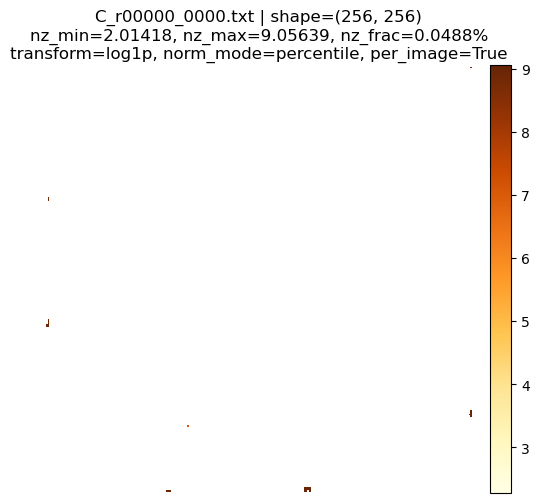

In [6]:
# 预览首个文件渲染效果

if not candidates:
    print('无候选文件可预览。')
else:
    sample_path = candidates[0]
    print('预览文件:', sample_path)

    data_raw = load_matrix_txt(sample_path)
    data = preprocess_matrix(data_raw)

    cmap = get_cmap(cmap_name)
    if per_image_normalize:
        norm = build_norm(data)
    else:
        norm = global_norm if global_norm is not None else build_norm(data)

    masked = np.ma.masked_equal(data, 0)
    plt.figure(figsize=(6, 6))
    im = plt.imshow(masked, cmap=cmap, norm=norm, interpolation=interpolation)

    nz = data[data > 0]
    nz_info = f"nz_min={float(nz.min()):.6g}, nz_max={float(nz.max()):.6g}, nz_frac={100.0*(nz.size/data.size):.4f}%" if nz.size else 'no hits'
    plt.title(f"{sample_path.name} | shape={data.shape}\n{nz_info}\ntransform={transform_mode}, norm_mode={norm_mode}, per_image={per_image_normalize}")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.show()

In [7]:
# 批量渲染并保存 PNG（保持相对目录结构，输出到 out_dir/channel_name/...）

def render_array_and_save(
    data: np.ndarray,
    path_in: Path,
    base_in: Path,
    base_out: Path,
    norm: colors.Normalize,
    cmap: colors.Colormap,
    *,
    scale: int = 4,
    interpolation: str = 'nearest',
) -> Path:
    rgba = map_to_rgba(data, norm=norm, cmap=cmap)
    img = Image.fromarray(rgba, mode='RGBA')
    if scale and scale > 1:
        img = img.resize(
            (img.width * scale, img.height * scale),
            Image.NEAREST if interpolation == 'nearest' else Image.BILINEAR,
        )
    rel = path_in.relative_to(base_in)
    out_png = base_out.joinpath(rel).with_suffix('.png')
    out_png.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_png)
    return out_png


success, failed = 0, 0
errors: Dict[str, str] = {}

base_out = Path(out_dir) / channel_name
base_out.mkdir(parents=True, exist_ok=True)

cmap = get_cmap(cmap_name)

for p in tqdm(candidates, desc='渲染中'):
    try:
        data = preprocess_matrix(load_matrix_txt(p))
        if per_image_normalize:
            norm = build_norm(data)
        else:
            norm = global_norm if global_norm is not None else build_norm(data)
        _ = render_array_and_save(data, p, in_path, base_out, norm, cmap, scale=scale, interpolation=interpolation)
        success += 1
    except Exception as e:
        failed += 1
        errors[str(p)] = str(e)

print(f"完成：成功 {success}，失败 {failed}。输出目录：{base_out}")

C:\Users\27964\AppData\Local\Temp\ipykernel_35624\40590239.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(name).copy()
渲染中:   0%|          | 0/11784 [00:00<?, ?it/s]C:\Users\27964\AppData\Local\Temp\ipykernel_35624\3187652761.py:15: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgba, mode='RGBA')
渲染中: 100%|██████████| 11784/11784 [06:29<00:00, 30.26it/s]

完成：成功 11784，失败 0。输出目录：D:\Project\Timepix\ProcessData\Images_ToA\ToA


In [ ]:
# 写入日志（参数 + 成功/失败 + 错误明细）

summary = {
    'input_dir': str(in_dir),
    'output_dir': str(out_dir),
    'channel_name': channel_name,
    'include_glob': include_glob,
    'exclude_regex': exclude_regex,
    'scale': scale,
    'interpolation': interpolation,
    'cmap_name': cmap_name,
    'hit_threshold': hit_threshold,
    'transform_mode': transform_mode,
    'per_image_normalize': per_image_normalize,
    'norm_mode': norm_mode,
    'pmin': pmin,
    'pmax': pmax,
    'global_norm_max_files': global_norm_max_files,
    'global_norm_max_nonzero_per_file': global_norm_max_nonzero_per_file,
    'files_total': len(candidates),
    'success': success,
    'failed': failed,
    'errors': errors,
}

log_path = Path(out_dir) / f'render_log_{channel_name}.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('日志已写入：', log_path)
if failed:
    print('失败明细（最多显示5条）：')
    for i, (k, v) in enumerate(errors.items()):
        print(f'[{i+1}] {k} -> {v}')
        if i >= 4:
            break

In [ ]:
# 简单自检：0 映射为白色、log1p 不报错、裁剪尺寸正确

def _unit_test_zero_is_white():
    arr = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=np.float64)
    arr = transform_values(arr, mode='linear')
    norm = build_norm_percentile(arr, pmin=0.0, pmax=100.0)
    cmap = get_cmap('YlOrBr')
    rgba = map_to_rgba(arr, norm, cmap)
    white = rgba[0, 0, :3]
    assert np.allclose(white, np.array([255, 255, 255])), f'0 未映射为白色: {white}'

def _unit_test_log1p_ok():
    arr = np.array([[0.0, 10000.0], [20000.0, 50000.0]], dtype=np.float64)
    out = transform_values(arr, mode='log1p')
    assert np.isfinite(out).all(), 'log1p 后出现非有限值'

def _unit_test_crop_100():
    arr = np.zeros((100, 100), dtype=np.float64)
    arr[50, 50] = 123.0
    cropped = center_crop_for_shape(arr, target_shape=(100, 100), crop_size=32)
    assert cropped.shape == (32, 32)
    assert cropped[16, 16] == 123.0

_unit_test_zero_is_white()
_unit_test_log1p_ok()
_unit_test_crop_100()
print('自检通过。')